In [9]:
!nvidia-smi

Thu Jun  4 12:48:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
!pip install roboflow ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.6 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_ROBOFLOW_DATA_API_KEY")
project = rf.workspace("goodwills-workspace").project("helmet_detection-m0yd8")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Helmet_Detection-1 in yolov11:: 100%|██████████| 2998/2998 [00:00<00:00, 7876.90it/s]


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import os

print(dataset.location)
print(os.listdir(dataset.location))

/content/Helmet_Detection-1
['test', 'data.yaml', 'train', 'README.roboflow.txt', 'valid']


In [14]:
with open("/content/Helmet_Detection-1/data.yaml", "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['With Helmet', 'Without Helmet']

roboflow:
  workspace: goodwills-workspace
  project: helmet_detection-m0yd8
  version: 1
  license: Private
  url: https://app.roboflow.com/goodwills-workspace/helmet_detection-m0yd8/1


In [15]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [16]:
!pip install ultralytics -q

In [17]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [19]:
results = model.train(
    data="/content/Helmet_Detection-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="helmet_training",
    name="yolo11n_helmet"
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Helmet_Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_helmet-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [21]:
print(results.save_dir)

/content/runs/detect/helmet_training/yolo11n_helmet-2


In [22]:
!ls /content/runs/detect/helmet_training/yolo11n_helmet-2/weights

best.pt  last.pt


In [23]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/detect/helmet_training/yolo11n_helmet-2/weights/best.pt"
)

In [25]:
from google.colab import files

uploaded = files.upload()

Saving BikesHelmets59.png to BikesHelmets59.png


In [26]:
results = model.predict(
    source="BikesHelmets59.png",
    conf=0.25,
    save=True
)


image 1/1 /content/BikesHelmets59.png: 448x640 3 With Helmets, 279.7ms
Speed: 7.9ms preprocess, 279.7ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


In [28]:
import os

for root, dirs, files in os.walk("/content/runs/detect"):
    for file in files:
        if file.endswith((".png", ".jpg", ".jpeg")):
            print(os.path.join(root, file))

/content/runs/detect/helmet_training/yolo11n_helmet-2/results.png
/content/runs/detect/helmet_training/yolo11n_helmet-2/BoxR_curve.png
/content/runs/detect/helmet_training/yolo11n_helmet-2/BoxP_curve.png
/content/runs/detect/helmet_training/yolo11n_helmet-2/val_batch2_pred.jpg
/content/runs/detect/helmet_training/yolo11n_helmet-2/train_batch0.jpg
/content/runs/detect/helmet_training/yolo11n_helmet-2/train_batch3280.jpg
/content/runs/detect/helmet_training/yolo11n_helmet-2/labels.jpg
/content/runs/detect/helmet_training/yolo11n_helmet-2/confusion_matrix_normalized.png
/content/runs/detect/helmet_training/yolo11n_helmet-2/train_batch3281.jpg
/content/runs/detect/helmet_training/yolo11n_helmet-2/BoxF1_curve.png
/content/runs/detect/helmet_training/yolo11n_helmet-2/BoxPR_curve.png
/content/runs/detect/helmet_training/yolo11n_helmet-2/val_batch1_labels.jpg
/content/runs/detect/helmet_training/yolo11n_helmet-2/val_batch1_pred.jpg
/content/runs/detect/helmet_training/yolo11n_helmet-2/val_batc

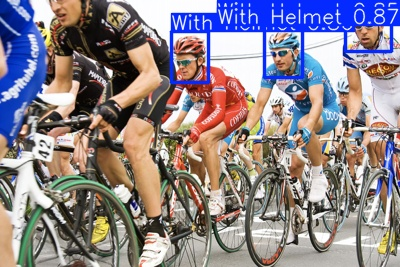

In [29]:
from PIL import Image
from IPython.display import display

display(Image.open("/content/runs/detect/predict/BikesHelmets59.jpg"))

In [30]:
print(model.names)

for box in results[0].boxes:
    print(
        "Class:",
        model.names[int(box.cls)],
        "| Confidence:",
        round(float(box.conf), 3)
    )

{0: 'With Helmet', 1: 'Without Helmet'}
Class: With Helmet | Confidence: 0.873
Class: With Helmet | Confidence: 0.862
Class: With Helmet | Confidence: 0.848


In [31]:
metrics = model.val()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1855.5±392.6 MB/s, size: 43.9 KB)
val: Scanning /content/Helmet_Detection-1/valid/labels.cache... 130 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 32.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.8it/s 5.0s
                   all        130        238      0.738      0.704      0.713      0.438
           With Helmet         86        148      0.773      0.831      0.814      0.521
        Without Helmet         49         90      0.702      0.578      0.612      0.355
Speed: 9.3ms preprocess, 8.5ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/runs/detect/val


In [32]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Precision: 0.7377069381454777
Recall: 0.7044294294294293
mAP50: 0.7127905702740651
mAP50-95: 0.43807800950407644


In [33]:
precision = metrics.box.mp
recall = metrics.box.mr

f1 = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7377069381454777
Recall: 0.7044294294294293
F1 Score: 0.7206842420842814


In [34]:
metrics = model.val()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1606.9±644.8 MB/s, size: 47.0 KB)
val: Scanning /content/Helmet_Detection-1/valid/labels.cache... 130 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 34.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.7it/s 3.3s
                   all        130        238      0.738      0.704      0.713      0.438
           With Helmet         86        148      0.773      0.831      0.814      0.521
        Without Helmet         49         90      0.702      0.578      0.612      0.355
Speed: 5.0ms preprocess, 5.1ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/runs/detect/val-2


In [35]:
print(dir(metrics.box))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'all_ap', 'ap', 'ap50', 'ap_class_index', 'class_result', 'clear_image_metrics', 'curves', 'curves_results', 'f1', 'f1_curve', 'fitness', 'image_metrics', 'map', 'map50', 'map75', 'maps', 'mean_results', 'mp', 'mr', 'nc', 'p', 'p_curve', 'prec_values', 'px', 'r', 'r_curve', 'update', 'update_image_metrics']
